In [130]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import median_filter, binary_dilation
from scipy.stats import median_abs_deviation

In [131]:
# file locations
fp = '/Users/jeroenmatthijssen/Downloads/MSc Astronomy/Courses/Radio Astronomy/telescope_design/Data/'
names = ['cold_load', 'hot_load', 'vega', 'capella']
files = ['HI_measurement_n1_cold', 'HI_measurement_n2_hot', 'HI_measurement_n3_vega', 'HI_measurement_n4_capella']
labels = ['Cold load (zenith)', 'Hot load', 'Vega', 'Capella']
save_figs = False # set to True to save all the plots to fp

# define GNU radio constants
samp_rate = 16e6
center_frequency = 1.417e9
dt = 1/samp_rate
vector_length = 2**15
nbin = 32 # channels per bin (488 Hz * 32 = 15.6 kHz = 3.3 km/s per bin)

# selection of the data
f_min, f_max = 1.418e9, 1.424e9 # use frequencies between 1.418 GHz and 1.424 GHz
line_window = (1.4198e9, 1.4212e9) # 21cm line, these channels are left out of the baseline fit

# the science measurements and the frequencies used for the gaussian fit of the line
science_names = ['vega', 'capella', 'cold_load']
science_labels = ['Vega', 'Capella', 'Cold load (zenith)']
fit_window = [(1.4201e9, 1.4207e9), (1.4201e9, 1.4209e9), (1.4201e9, 1.4209e9)]

# calibration
T_hot = 295 # temperature of the microwave absorber
T_cold = 10 # temperature of the cold load = sky at zenith (T_cmb + T_rsb(sky brightness) + T_atm + T_spill)

# conversion to radial velocity
c_kms = 3e5 # speed of light [km/s]
rest_freq = 1.4204058 # rest frequency of the 21cm line in GHz

In [132]:
### loading, binning and cleaning

def bin_channels(y, nbin=nbin):
    """Average every nbin neighbouring channels."""
    return y.reshape(*y.shape[:-1], -1, nbin).mean(axis=-1)

def remove_spikes(y, kernel=101, nsigma=5, grow=3):
    """Replace narrow spikes in a 1D spectrum by linear interpolation.
    Returns an array of the same shape as y."""
    y = np.asarray(y, dtype=float)
    base = median_filter(y, size=kernel, mode='nearest')
    resid = (y - base) / base
    sigma = median_abs_deviation(resid, scale='normal')
    bad = binary_dilation(np.abs(resid) > nsigma * sigma, iterations=grow)  # also drop spike wings

    x = np.arange(y.size)
    out = y.copy()
    out[bad] = np.interp(x[bad], x[~bad], y[~bad])
    return out

def load_spectrum(file):
    """Load a GNU radio file, average all integrations, remove spikes and bin the channels."""
    raw = np.fromfile(fp + file, dtype=np.float32)
    N_spectra = raw.size // vector_length # number of integrated spectra
    spectra = raw[:N_spectra * vector_length].reshape(N_spectra, vector_length)
    spectrum = remove_spikes(spectra.mean(axis=0, dtype=np.float64)) # take the mean of all spectra to remove noise
    return bin_channels(spectrum)

In [133]:
### baseline fitting

def fit_baseline(x, y, mask, order):
    """Polynomial baseline fitted to the channels."""
    use = mask.copy()
    p = np.polyfit(x[use], y[use], order)
    return np.polyval(p, x)

In [134]:
### plotting and line fitting
def plot_spectrum(freq, curves, curve_labels, title, ylabel='Power spectral density [V$^2$/Hz]', fname=None):
    """Plotting spectra against frequency"""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(title)
    for y, label in zip(curves, curve_labels):
        ax.plot(freq/1e9, y, lw=0.8, label=label)
    ax.set_xlabel("frequency [GHz]")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    fig.tight_layout()
    if save_figs and fname:
        fig.savefig(fp + fname, dpi=300, bbox_inches='tight')
    plt.show()


# Gaussian function
def gauss(x, b, a, x0, sigma):
    """Gaussian function."""
    return b + a * np.exp(-(x - x0)**2 / (2 * sigma**2))


def fit_line(freq, T, window):
    """Fit a gaussian to the 21cm line within window [Hz]. Frequencies in the output are in GHz."""
    sel = (freq > window[0]) & (freq < window[1])
    f, Tb = freq[sel]/1e9, T[sel]

    # set initial guess for the parameters
    p0 = [np.mean(Tb), np.max(Tb) - np.mean(Tb), np.median(f), np.std(f)]
    popt, pcov = curve_fit(gauss, f, Tb, p0=p0)
    b_fit, a_fit, x0_fit, sigma_fit = popt
    perr = np.sqrt(np.diag(pcov))
    return f, Tb, gauss(f, b_fit, a_fit, x0_fit, sigma_fit), popt, perr


def v_rad(f, f_0):
    """Frequency to v_rad."""
    return c_kms * (f_0 - f) / f_0

def plot_line(f, Tb, fit, x0, sigma, title, velocity=False, fname=None):
    """Plot the measured 21cm line with its gaussian fit, against frequency [GHz] or radial velocity [km/s]."""
    if velocity:
        f, x0, sigma = v_rad(f, rest_freq), v_rad(x0, rest_freq), c_kms * sigma / rest_freq
        xlabel = 'Radial velocity [km/s]'
        line_label = fr'$v_0 = {x0:.2f}$ km/s'
        span_label = fr'$v_0 \pm \sigma_v$, $\sigma_v = {sigma:.0f}$ km/s'
    else:
        xlabel = 'Frequency [GHz]'
        line_label = fr'$\nu_0 = {x0:.6f}$ GHz'
        span_label = fr'$\nu_0 \pm \sigma$, $\sigma = {sigma*1e3:.3f}$ MHz'

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.set_title(title)
    ax.plot(f, Tb, color='tab:grey', label='Measured spectrum')
    ax.plot(f, fit, color='tab:red', lw=3, label='Gaussian fit')
    ax.axvline(x0, color='blue', linestyle='--', lw=1.5, label=line_label)
    ax.axvspan(x0 - sigma, x0 + sigma, color='tab:blue', alpha=0.15, label=span_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Brightness temperature $T_b$ [K]')
    ax.set_xlim(f.min(), f.max())
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    fig.tight_layout()
    if save_figs and fname:
        fig.savefig(fp + fname, dpi=300, bbox_inches='tight')
    plt.show()

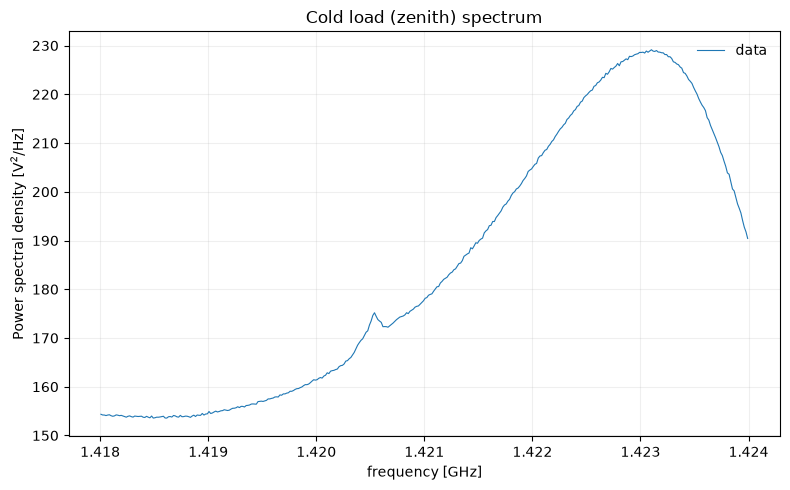

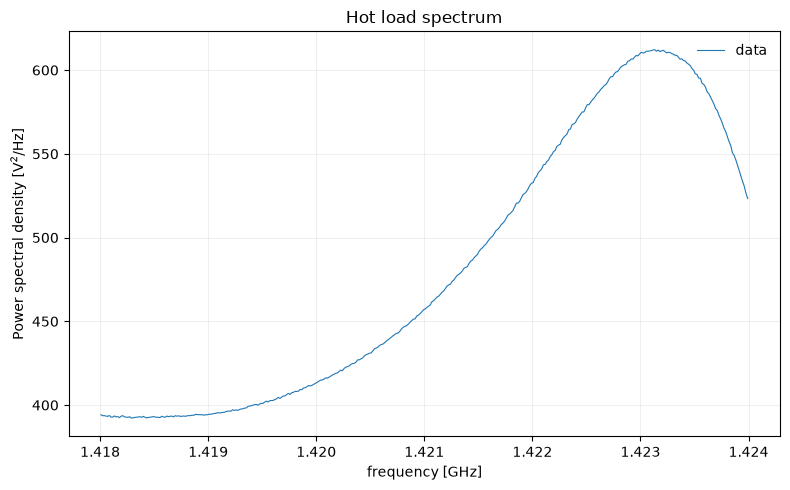

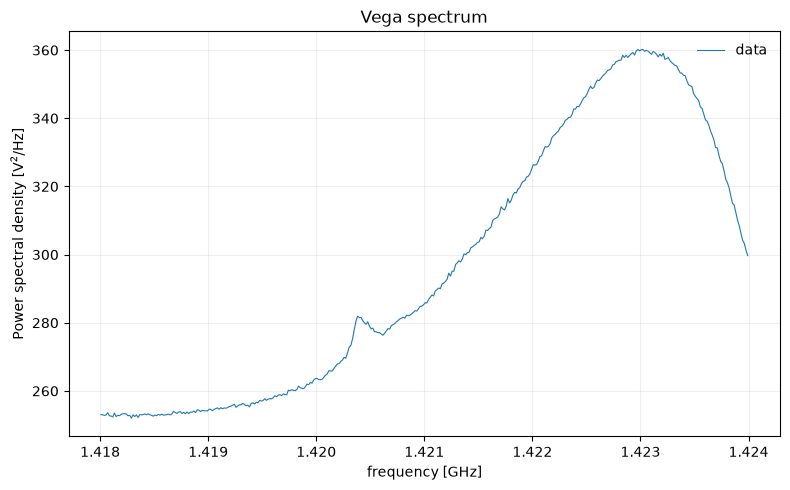

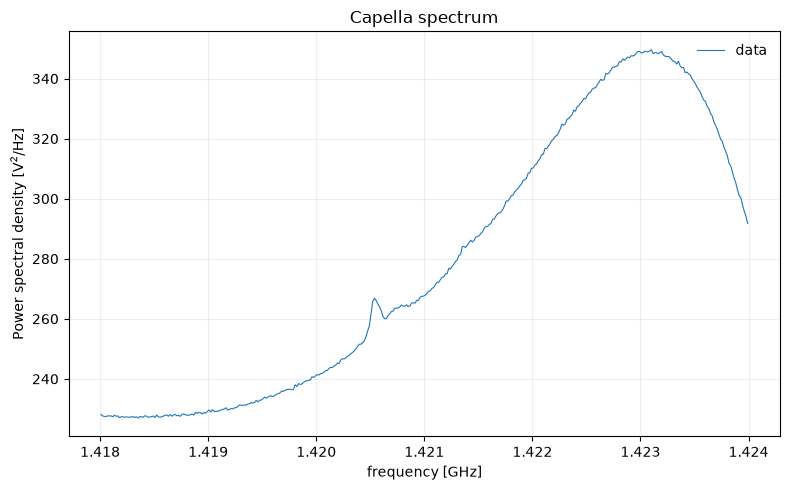

In [135]:
# load, bin and clean all the data
spectra = [load_spectrum(file) for file in files]

# calculate the autocorrelator frequency
frequency = np.fft.fftfreq(vector_length, d=dt)
frequency = bin_channels(np.fft.fftshift(frequency) + center_frequency) # center around 1.42Ghz

# use frequencies between 1.418G-1.424GHz
idx = (frequency > f_min) & (frequency < f_max)
freq = frequency[idx]
spectra = [spectrum[idx] for spectrum in spectra]

# visualise the mean autocorrelated signal
for name, label, spectrum in zip(names, labels, spectra):
    plot_spectrum(freq, [spectrum], ['data'], f'{label} spectrum', fname=f'{name}_spectrum_plot.png')

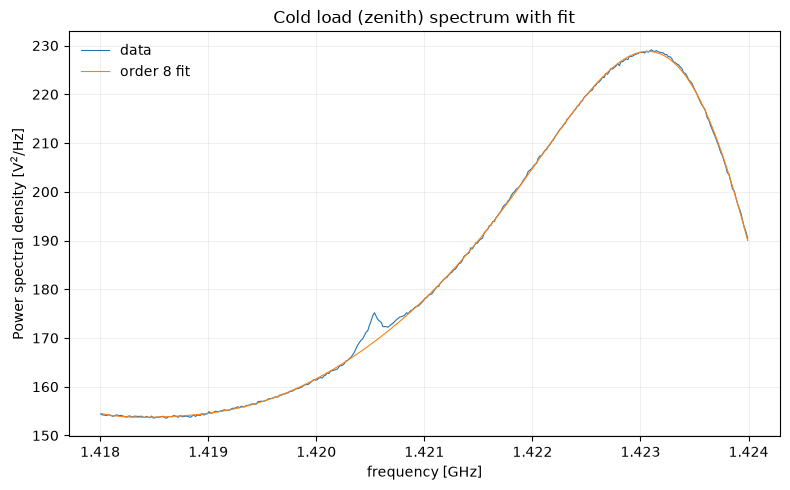

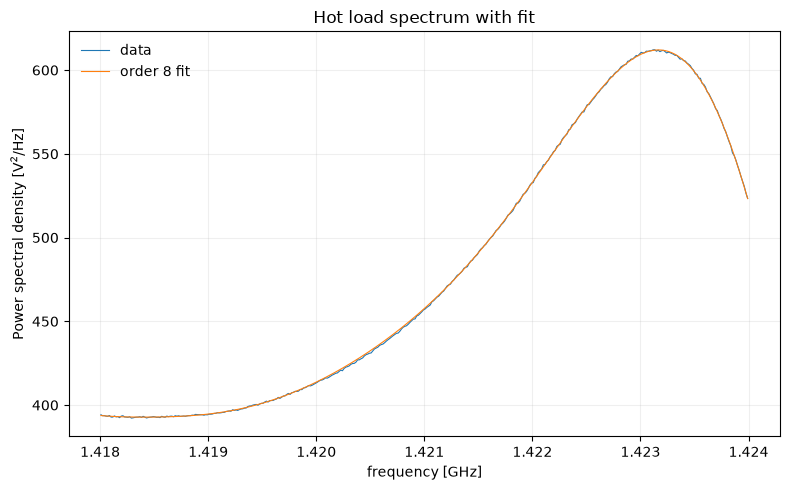

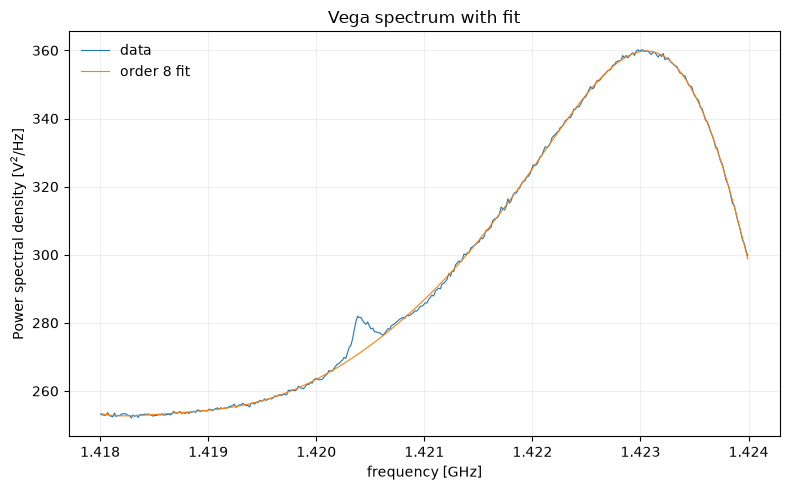

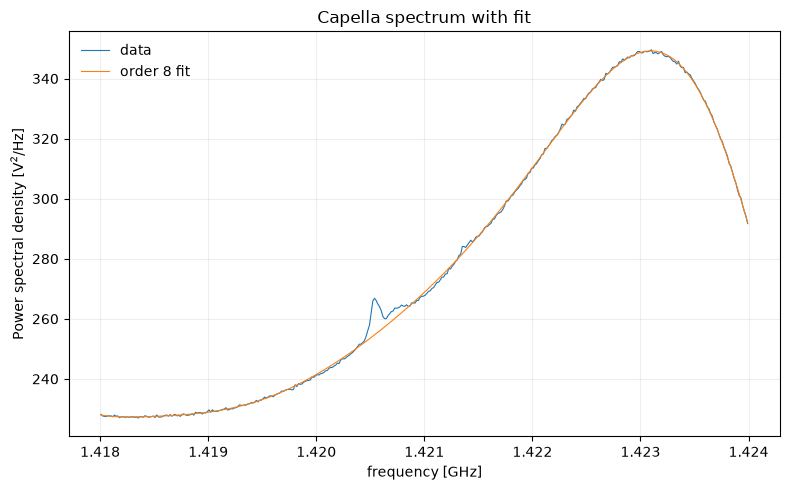

In [136]:
### baseline: fit and check

# fit the baseline to the line-free channels of every spectrum
x = 2 * (freq - freq.min()) / (freq.max() - freq.min()) - 1
line = (freq > line_window[0]) & (freq < line_window[1]) # channels with the 21cm line

baseline = [fit_baseline(x, spectrum, ~line, 8) for spectrum in spectra]

# visualise the data with its baseline, the shaded region is left out of the fit
for name, label, spectrum, base in zip(names, labels, spectra, baseline):
    plot_spectrum(freq, [spectrum, base], ['data', f'order 8 fit'], f'{label} spectrum with fit', fname=f'{name}_spectrum_with_baseline_plot.png')

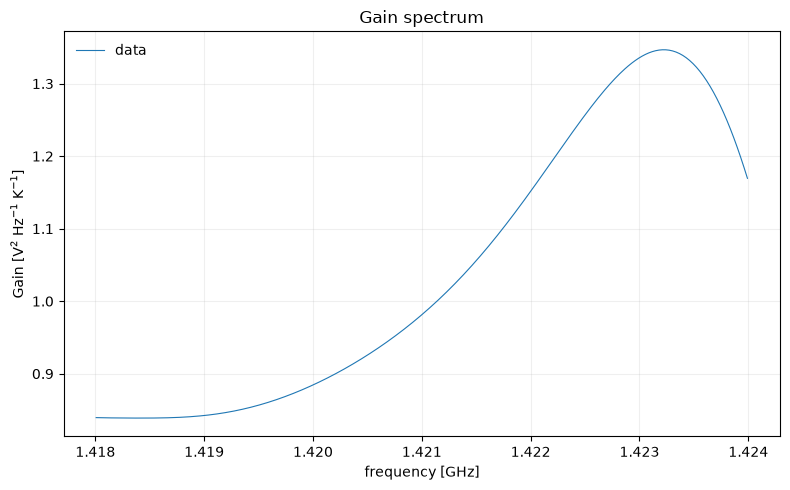

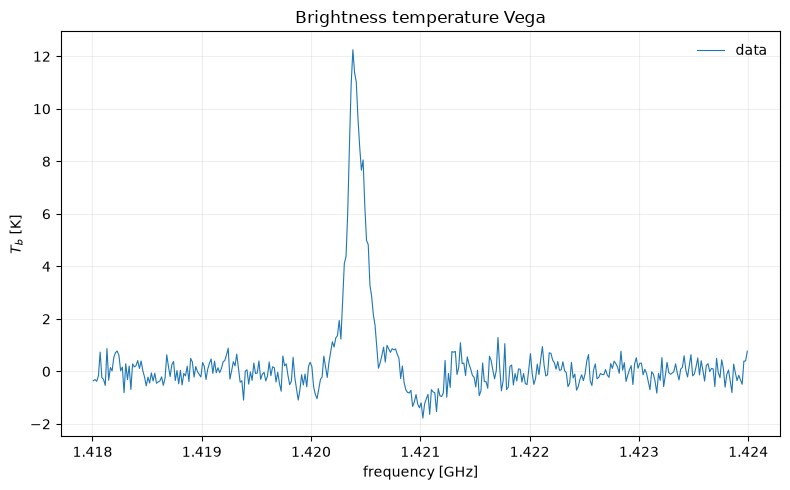

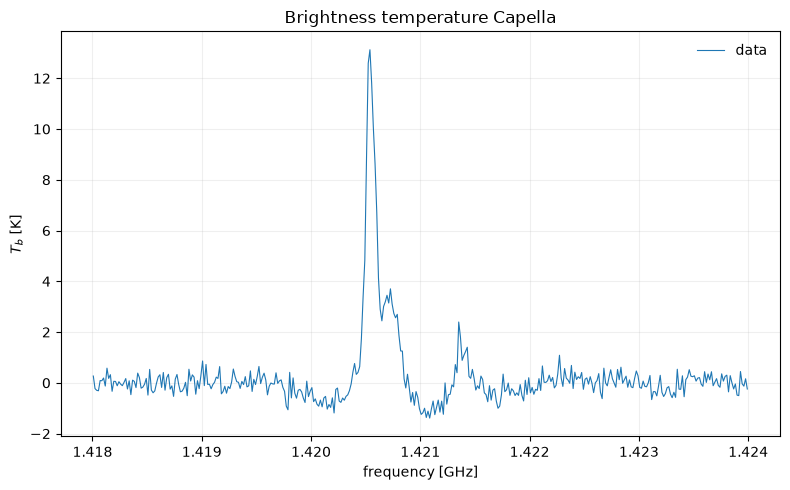

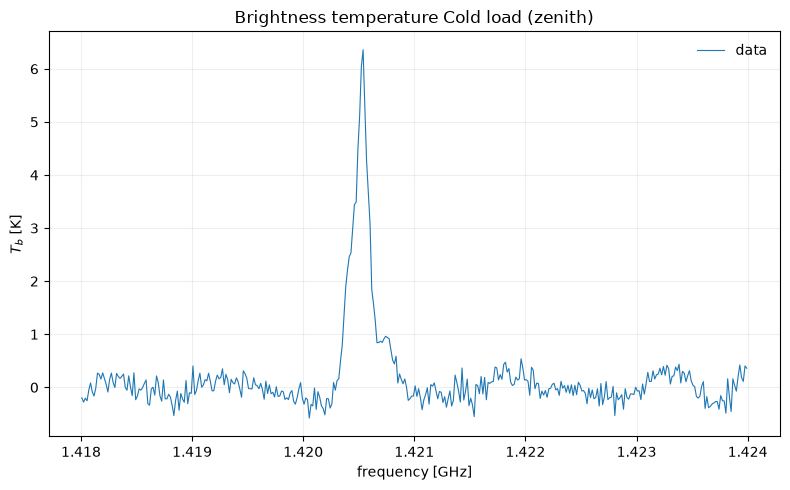

In [137]:
### baseline subtraction and conversion to temperature

# the hot and cold baselines only give the gain, which sets the scale from V^2/Hz to K
G = (baseline[1] - baseline[0]) / (T_hot - T_cold) # hot load - cold load

# subtracting the baseline removes the bandpass and the continuum, what remains is the line
T_cold_load = (spectra[0] - baseline[0]) / G
T_vega = (spectra[2] - baseline[2]) / G
T_capella = (spectra[3] - baseline[3]) / G
T_line = [T_vega, T_capella, T_cold_load] # same order as science_names

# plot the gain
plot_spectrum(freq, [G], ['data'], 'Gain spectrum', ylabel='Gain [V$^2$ Hz$^{-1}$ K$^{-1}$]', fname='gain_plot.png')

# plot the baseline subtracted spectra, the line free channels should scatter around 0
for name, label, T in zip(science_names, science_labels, T_line):
    plot_spectrum(freq, [T], ['data'], f'Brightness temperature {label}', ylabel='$T_b$ [K]', fname=f'{name}_brightness_temperature_plot.png')

Vega
Central frequency 21cm line: 1.420410 +- 0.000003 GHz
Standard deviation: -0.074 +- 0.003 MHz
FWHM: -0.174 MHz
Radial velocity: -0.91 km/s



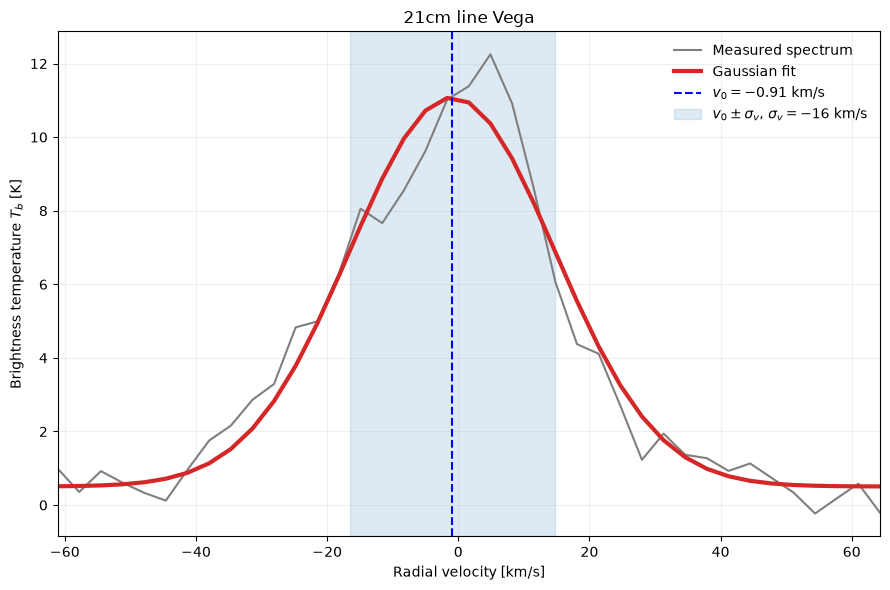

Capella
Central frequency 21cm line: 1.420548 +- 0.000003 GHz
Standard deviation: -0.045 +- 0.003 MHz
FWHM: -0.105 MHz
Radial velocity: -30.03 km/s



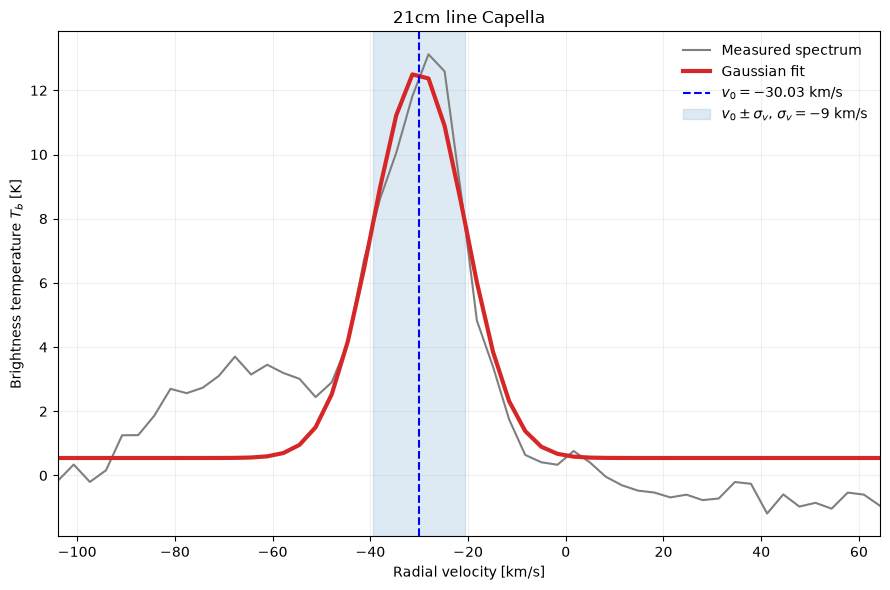

Cold load (zenith)
Central frequency 21cm line: 1.420522 +- 0.000003 GHz
Standard deviation: 0.077 +- 0.004 MHz
FWHM: 0.182 MHz
Radial velocity: -24.50 km/s



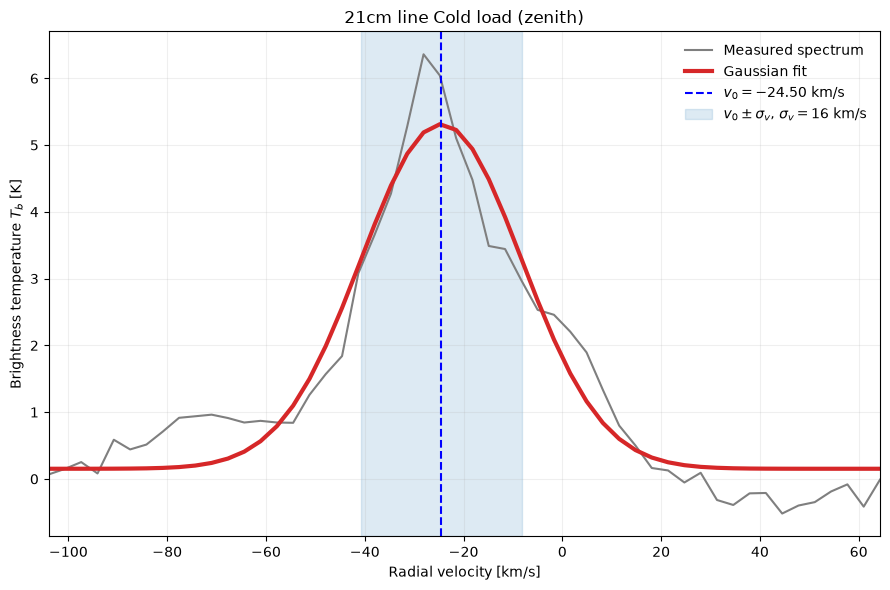

In [138]:
### gaussian fit of the 21cm line

results = []
for name, label, window, T in zip(science_names, science_labels, fit_window, T_line):
    f, Tb, gauss_fit, popt, perr = fit_line(freq, T, window)
    b_fit, a_fit, x0_fit, sigma_fit = popt
    results.append((popt, perr))

    print(f"{label}")
    print(f"Central frequency 21cm line: {x0_fit:.6f} +- {perr[2]:.6f} GHz")
    print(f"Standard deviation: {sigma_fit*1e3:.3f} +- {perr[3]*1e3:.3f} MHz")
    print(f"FWHM: {2*np.sqrt(2*np.log(2))*sigma_fit*1e3:.3f} MHz")
    print(f"Radial velocity: {v_rad(x0_fit, rest_freq):.2f} km/s\n")

    # plot_line(f, Tb, gauss_fit, x0_fit, sigma_fit, f'21cm line {label}', fname=f'{name}_21cm_line_plot.png')
    plot_line(f, Tb, gauss_fit, x0_fit, sigma_fit, f'21cm line {label}', velocity=True, fname=f'{name}_21cm_line_radial_velocity_plot.png')

Text(0.5, 1.0, 'Measured $T_b$ vs. literature cold load (zenith)')

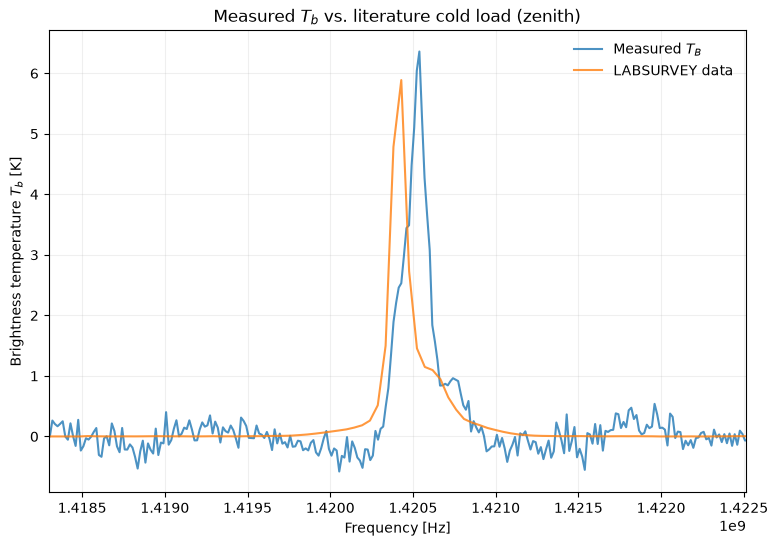

In [139]:
freqs, T_LABSURVEY = np.loadtxt('LABSURVEY_results.txt')

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(freq, T_cold_load, alpha=.8, label=r'Measured $T_{B}$')
ax.plot(freqs, T_LABSURVEY, alpha=.8, label='LABSURVEY data')

ax.grid(alpha=0.2)
ax.legend(frameon=False)
ax.set_xlim((freqs).min(), (freqs).max())
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Brightness temperature $T_b$ [K]')
ax.set_title(r'Measured $T_b$ vs. literature cold load (zenith)')
# fig.savefig(fp + 'measured_vs_literature_cold_load.png', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Measured $T_b$ vs. literature Vega')

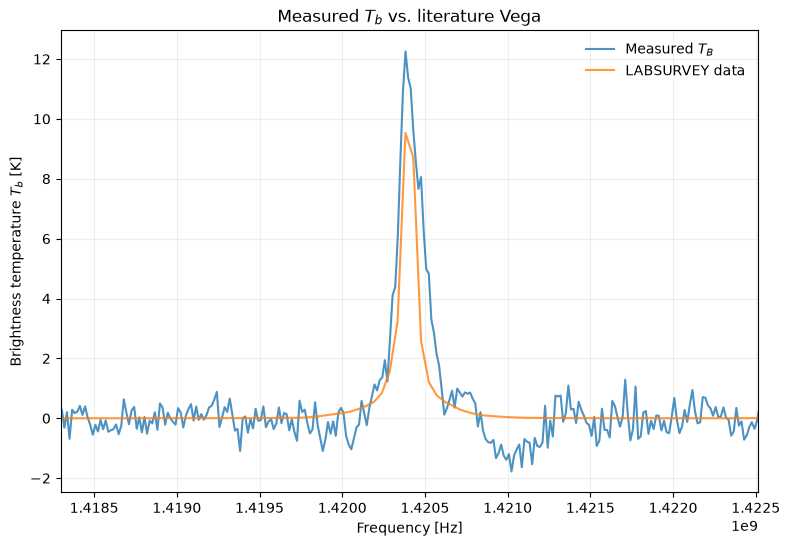

In [140]:
freqs, T_LABSURVEY = np.loadtxt('LABSURVEY_results_vega.txt')

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(freq, T_vega, alpha=.8, label=r'Measured $T_{B}$')
ax.plot(freqs, T_LABSURVEY, alpha=.8, label='LABSURVEY data')

ax.grid(alpha=0.2)
ax.legend(frameon=False)
ax.set_xlim((freqs).min(), (freqs).max())
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Brightness temperature $T_b$ [K]')
ax.set_title(r'Measured $T_b$ vs. literature Vega')
# fig.savefig(fp + 'measured_vs_literature_vega.png', dpi=300, bbox_inches='tight')

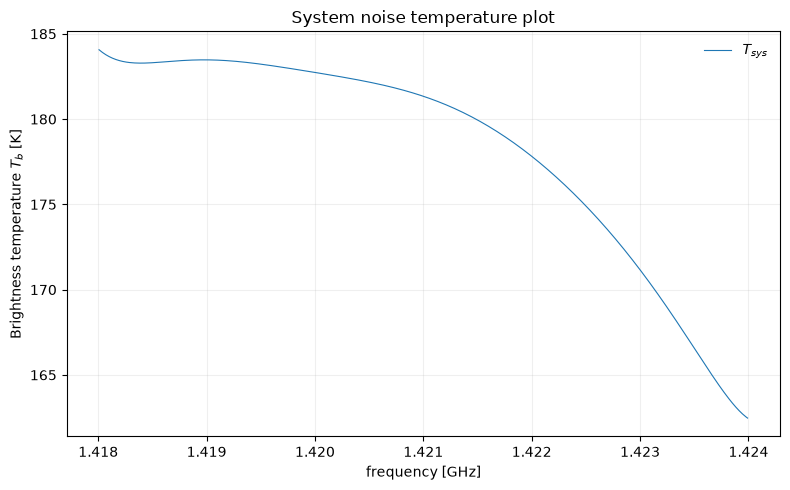

In [ ]:
# plot the system noise temperature
Y = baseline[1] / baseline[0]
noise_temp = (T_hot-Y*T_cold)/(Y-1)
sys_temp = noise_temp + T_cold

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title('System noise temperature plot')
ax.plot(freq/1e9, sys_temp, lw = 0.8, label = '$T_{sys}$')
ax.set_xlabel("frequency [GHz]")
ax.set_ylabel('Brightness temperature $T_b$ [K]')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
# plt.savefig(fp + 'system_temp_plot.png', dpi=300, bbox_inches='tight')
plt.show()